# Examining PyTorch Model File - node0_round10.pt

This notebook loads and examines the content of a PyTorch model file `node0_round10.pt`, which appears to contain model weights saved during training at round 10 for node 0.

We'll load the file, examine its structure, and visualize components of the model.

## 1. Import Required Libraries

In [1]:
import torch
import os
import glob
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from collections import OrderedDict

## 2. Find and Load PyTorch Model File

First, let's find the available node0_round10.pt files in the workspace:

In [3]:
# Search for all node0_round10.pt files in the workspace
model_files = glob.glob('/home/pouponne/decentralized/shatter-poisoning/test_scripts/test_compare_exp/CIFAR10/1a_2chunk_clipdef-2025-07-30T00:01/machine0/saved_weights/exp_20250730_000205_atk1/node0_round10.pt', recursive=True)

print(f"Found {len(model_files)} node0_round10.pt files:")
for idx, file_path in enumerate(model_files, 1):
    print(f"{idx}. {file_path}")

# Use the most recent file (assuming the last one in the list)
if model_files:
    model_path = model_files[0]
    print(f"\nWe'll use this file: {model_path}")
else:
    print("No node0_round10.pt files found in the workspace.")

Found 1 node0_round10.pt files:
1. /home/pouponne/decentralized/shatter-poisoning/test_scripts/test_compare_exp/CIFAR10/1a_2chunk_clipdef-2025-07-30T00:01/machine0/saved_weights/exp_20250730_000205_atk1/node0_round10.pt

We'll use this file: /home/pouponne/decentralized/shatter-poisoning/test_scripts/test_compare_exp/CIFAR10/1a_2chunk_clipdef-2025-07-30T00:01/machine0/saved_weights/exp_20250730_000205_atk1/node0_round10.pt


In [4]:
# Let's use a specific file path if you know which one you want to examine
# You can modify this path to use a specific file from the list above
specific_path = "/home/pouponne/decentralized/shatter-poisoning/test_scripts/test_compare_exp/CIFAR10/1a_2chunk_clipdef-2025-07-29T23:51/machine0/saved_weights/exp_20250729_235147_atk1/node0_round10.pt"

# Check if the specific file exists
if os.path.exists(specific_path):
    model_path = specific_path
    print(f"Using specific model file: {model_path}")
elif model_files:
    # Use the first one found if specific path doesn't exist
    model_path = model_files[0]
    print(f"Using found model file: {model_path}")
else:
    print("No model file found!")
    model_path = None

Using specific model file: /home/pouponne/decentralized/shatter-poisoning/test_scripts/test_compare_exp/CIFAR10/1a_2chunk_clipdef-2025-07-29T23:51/machine0/saved_weights/exp_20250729_235147_atk1/node0_round10.pt


In [5]:
# Load the model file
if model_path:
    try:
        # Load the PyTorch model
        model_data = torch.load(model_path, map_location=torch.device('cpu'))
        print(f"Successfully loaded model from {model_path}")
        print(f"Type of loaded data: {type(model_data)}")
    except Exception as e:
        print(f"Error loading model: {str(e)}")
        model_data = None
else:
    model_data = None
    print("No model path provided.")

Successfully loaded model from /home/pouponne/decentralized/shatter-poisoning/test_scripts/test_compare_exp/CIFAR10/1a_2chunk_clipdef-2025-07-29T23:51/machine0/saved_weights/exp_20250729_235147_atk1/node0_round10.pt
Type of loaded data: <class 'dict'>


/tmp/ipykernel_2313752/423621350.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_data = torch.load(model_path, map_location=torch.device('cpu'))


## 3. Examine Model Structure

Let's examine the structure of the loaded data to understand what's in the .pt file:

In [6]:
if model_data is not None:
    # Check if it's a state_dict (dictionary)
    if isinstance(model_data, dict) or isinstance(model_data, OrderedDict):
        print("Model data is a dictionary (state_dict).")
        print(f"Number of keys: {len(model_data)}")
        print("\nKeys in the model dictionary:")
        for key in model_data.keys():
            print(f"- {key}")
            
    # Check if it's a torch.nn.Module
    elif hasattr(model_data, 'state_dict'):
        print("Model data is a torch.nn.Module.")
        state_dict = model_data.state_dict()
        print(f"Number of parameters: {len(state_dict)}")
        print("\nModel structure:")
        print(model_data)
        
    # Check if it's a single tensor
    elif isinstance(model_data, torch.Tensor):
        print("Model data is a single tensor.")
        print(f"Tensor shape: {model_data.shape}")
        print(f"Tensor dtype: {model_data.dtype}")
        
    # Otherwise, print type and try to extract more info
    else:
        print(f"Model data is of type: {type(model_data)}")
        print("Trying to extract more information...")
        try:
            print(model_data)
        except:
            print("Could not print the model data directly.")
else:
    print("No model data to examine.")

Model data is a dictionary (state_dict).
Number of keys: 14

Keys in the model dictionary:
- conv1.weight
- conv1.bias
- gn1.weight
- gn1.bias
- conv2.weight
- conv2.bias
- gn2.weight
- gn2.bias
- conv3.weight
- conv3.bias
- gn3.weight
- gn3.bias
- fc1.weight
- fc1.bias


## 4. Print Model Components

Let's examine the components of the model in more detail:

In [7]:
def print_tensor_info(tensor, name=""):
    """Print information about a tensor"""
    if not isinstance(tensor, torch.Tensor):
        print(f"{name}: Not a tensor, type is {type(tensor)}")
        return
    
    print(f"{name}:")
    print(f"  Shape: {tensor.shape}")
    print(f"  Data type: {tensor.dtype}")
    print(f"  Min value: {tensor.min().item()}")
    print(f"  Max value: {tensor.max().item()}")
    print(f"  Mean value: {tensor.mean().item()}")
    print(f"  Standard deviation: {tensor.std().item()}")
    print("-" * 50)

if model_data is not None:
    # If it's a dictionary (state_dict)
    if isinstance(model_data, dict) or isinstance(model_data, OrderedDict):
        print(f"Examining model state_dict with {len(model_data)} components:")
        print("=" * 80)
        
        # Keep track of total parameters
        total_params = 0
        
        # Print details for each parameter
        for key, value in model_data.items():
            if isinstance(value, torch.Tensor):
                print_tensor_info(value, key)
                total_params += value.numel()
                
        print(f"Total number of parameters: {total_params:,}")
            
    # If it's a torch.nn.Module
    elif hasattr(model_data, 'state_dict'):
        print("Examining torch.nn.Module:")
        print("=" * 80)
        
        # Get state dict
        state_dict = model_data.state_dict()
        
        # Print details for each parameter
        for key, value in state_dict.items():
            print_tensor_info(value, key)
            
    # If it's a tensor
    elif isinstance(model_data, torch.Tensor):
        print("Examining single tensor:")
        print("=" * 80)
        print_tensor_info(model_data, "model_data")
        
    # Otherwise
    else:
        print("Could not extract detailed component information.")
else:
    print("No model data available to examine components.")

Examining model state_dict with 14 components:
conv1.weight:
  Shape: torch.Size([32, 3, 5, 5])
  Data type: torch.float32
  Min value: -0.14126460254192352
  Max value: 0.13847625255584717
  Mean value: -0.0018092179670929909
  Standard deviation: 0.0673430934548378
--------------------------------------------------
conv1.bias:
  Shape: torch.Size([32])
  Data type: torch.float32
  Min value: -0.13007435202598572
  Max value: 0.15476681292057037
  Mean value: 0.007970471866428852
  Standard deviation: 0.06667979806661606
--------------------------------------------------
gn1.weight:
  Shape: torch.Size([32])
  Data type: torch.float32
  Min value: 0.9767581820487976
  Max value: 1.0199437141418457
  Mean value: 0.99843430519104
  Standard deviation: 0.010793866589665413
--------------------------------------------------
gn1.bias:
  Shape: torch.Size([32])
  Data type: torch.float32
  Min value: -0.03021768480539322
  Max value: 0.01436854898929596
  Mean value: -0.006082956679165363
 

## 5. Visualize Tensor Data

Let's create some visualizations of the model weights:

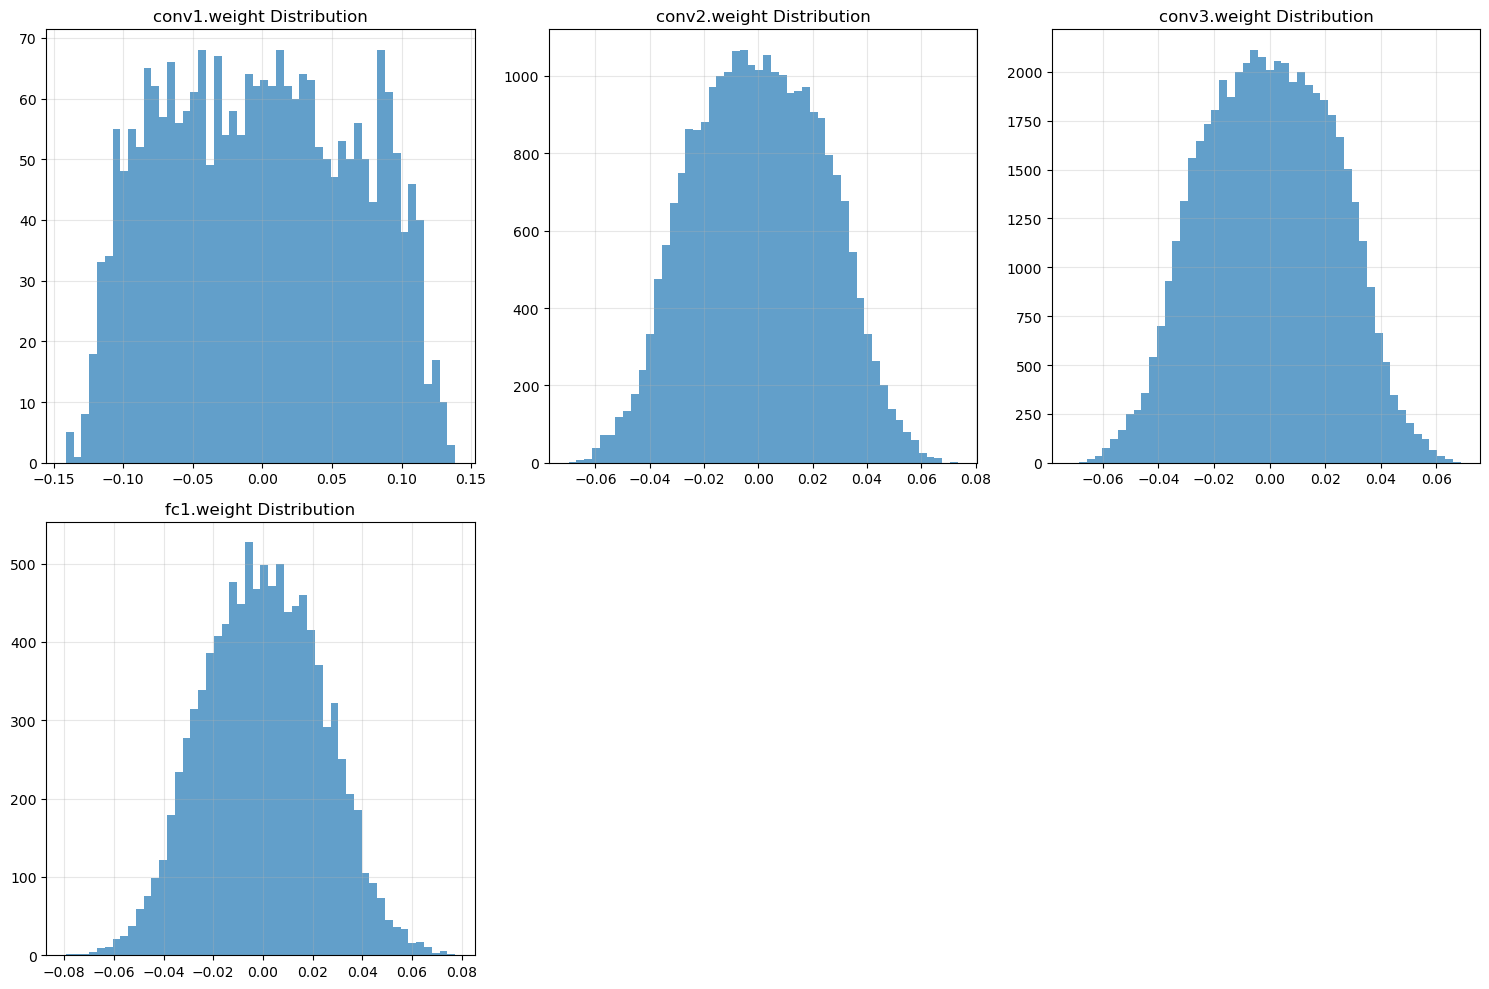

ValueError: Must pass 2-d input. shape=(32, 3, 5, 5)

<Figure size 1000x800 with 0 Axes>

In [8]:
if model_data is not None:
    plt.figure(figsize=(15, 10))
    
    # If it's a dictionary (state_dict)
    if isinstance(model_data, dict) or isinstance(model_data, OrderedDict):
        # Collect all weight matrices for visualization
        weight_tensors = []
        weight_names = []
        
        for key, value in model_data.items():
            if isinstance(value, torch.Tensor) and len(value.shape) >= 2:
                # Only select 2D tensors (weight matrices)
                weight_tensors.append(value)
                weight_names.append(key)
        
        # Plot histograms for weight distributions (max 6)
        num_plots = min(6, len(weight_tensors))
        
        for i in range(num_plots):
            plt.subplot(2, 3, i+1)
            tensor = weight_tensors[i].detach().flatten().numpy()
            plt.hist(tensor, bins=50, alpha=0.7)
            plt.title(f"{weight_names[i]} Distribution")
            plt.grid(alpha=0.3)
            
        plt.tight_layout()
        plt.show()
        
        # Create a heatmap for one of the weight matrices if available
        if len(weight_tensors) > 0:
            tensor_to_visualize = weight_tensors[0]
            
            # If tensor is too large, take a sample
            if tensor_to_visualize.numel() > 10000:
                if len(tensor_to_visualize.shape) == 2:
                    # For 2D tensors, take a corner
                    max_size = 100
                    tensor_to_visualize = tensor_to_visualize[:min(max_size, tensor_to_visualize.shape[0]), 
                                                           :min(max_size, tensor_to_visualize.shape[1])]
                else:
                    # For higher dimensional tensors, reshape to 2D
                    tensor_to_visualize = tensor_to_visualize.view(tensor_to_visualize.shape[0], -1)
                    tensor_to_visualize = tensor_to_visualize[:min(100, tensor_to_visualize.shape[0]), 
                                                           :min(100, tensor_to_visualize.shape[1])]
            
            plt.figure(figsize=(10, 8))
            sns.heatmap(tensor_to_visualize.detach().numpy(), cmap='viridis')
            plt.title(f"Heatmap of {weight_names[0]}")
            plt.show()
            
    # If it's a single tensor
    elif isinstance(model_data, torch.Tensor):
        tensor = model_data.detach().flatten().numpy()
        plt.hist(tensor, bins=50, alpha=0.7)
        plt.title("Tensor Value Distribution")
        plt.grid(alpha=0.3)
        plt.show()
        
        # Create a heatmap if tensor is 2D
        if len(model_data.shape) == 2:
            tensor_to_visualize = model_data
            
            # If tensor is too large, take a sample
            if tensor_to_visualize.numel() > 10000:
                tensor_to_visualize = tensor_to_visualize[:min(100, tensor_to_visualize.shape[0]), 
                                                       :min(100, tensor_to_visualize.shape[1])]
                
            plt.figure(figsize=(10, 8))
            sns.heatmap(tensor_to_visualize.detach().numpy(), cmap='viridis')
            plt.title("Heatmap of Tensor")
            plt.show()
    
    else:
        print("Could not visualize model data - not a dictionary or tensor.")
else:
    print("No model data available to visualize.")

## 6. Conclusion

In this notebook, we've loaded and explored the content of a PyTorch model file `node0_round10.pt`, which contains the model weights for node 0 at training round 10. We've examined the structure of the model, analyzed the key components, and visualized the weight distributions.

This analysis can be useful for understanding the model architecture, detecting potential issues like vanishing/exploding gradients, or comparing model weights across different training runs or nodes in a distributed training setting.